In [69]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import *
import requests
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *
import warnings
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
import torch.optim as optim
from xgboost import train

import CONSTANTS
from functions import *
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.base import clone
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from xgboostImplementation import XGBoost
import pickle
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

In [70]:
data = pd.read_csv(fullDataPath(COIN))
merged = dataSetup(data)
merged

,SMA_7,BB_Lower,BB_Upper,value,close,gradient
time,,,,,,
2015-07-20,283.615714,268.225209,299.188791,48.0,280.00,0.00
2015-07-21,285.645714,266.070954,300.106046,48.0,277.32,-2.68
2015-07-22,288.280000,263.804410,301.155590,48.0,277.89,0.57
2015-07-23,290.037143,263.024045,301.345955,48.0,277.39,-0.50
2015-07-24,291.622857,261.412051,301.912949,48.0,289.12,11.73
...,...,...,...,...,...,...
2025-06-22,104624.465714,101255.903690,110442.214310,40.0,100996.87,-1163.16
2025-06-23,104624.465714,101255.903690,110442.214310,37.0,105419.39,4422.52
2025-06-24,104624.465714,101255.903690,110442.214310,47.0,106141.00,721.61


# XGBoost Implementation

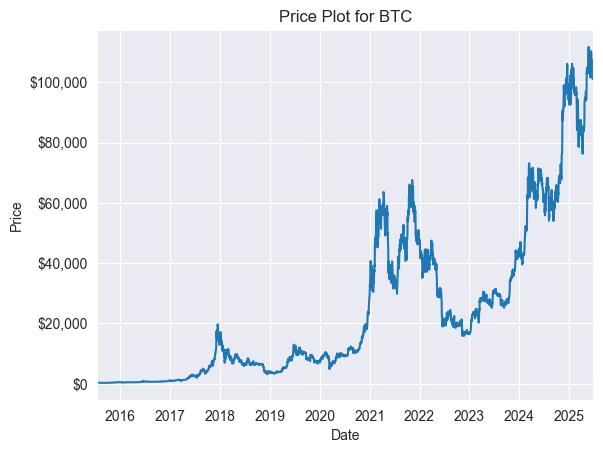

In [71]:
merged['close'].plot.line()
plt.title(f'Price Plot for {COIN}')
plt.xlabel('Date')
plt.ylabel('Price')
# format y axis to show currency
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))

In [72]:
trainingCols = [i.strip() for i in open('training_columns.txt', 'r').readlines()]
percentage = 0.8
X = merged[trainingCols]
y = merged['close']
n = len(data)


line = len(merged)-TEST_DAYS

X_train = X.iloc[:line].reset_index(drop=True)
X_test = X.iloc[line:].reset_index(drop=True)
y_train = y.iloc[:line].reset_index(drop=True)
y_test = y.iloc[line:].reset_index(drop=True)

X_train, X_test, y_train, y_test, sequence_scaler, target_scaler = normalize_regular(X_train, X_test, y_train, y_test)
X_train.shape, X_test.shape

((3623, 4), (7, 4))

In [5]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and fit model
xgb_model = XGBoost(
    base_estimator=RandomForestRegressor(n_estimators=50),
    n_estimators=50,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)
items = xgb_model.cross_validate(X_train, y_train, cv=5)

CV Folds: 100%|██████████| 5/5 [01:04<00:00, 12.97s/it]


In [6]:
items

{'test_scores': array([0.03763318, 0.04114808, 0.0437596 , 0.03838192, 0.03822957]),
 'test_score_mean': 0.039830470639037566,
 'test_score_std': 0.002309260360817988}

In [7]:
xgb_model.fit(X_train, y_train)
predictions = xgb_model.predict(X_test)
predictions = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
y_test_rescaled = target_scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
print('MSE =', mean_squared_error(y_test_rescaled, predictions, squared=False))
predictions

MSE = 1598.2748893620565


array([104493.92260313, 103051.60680659, 102735.73844133, 104280.94294807,
       104806.61702873, 105227.51468656, 104726.36783706])

<Axes: >

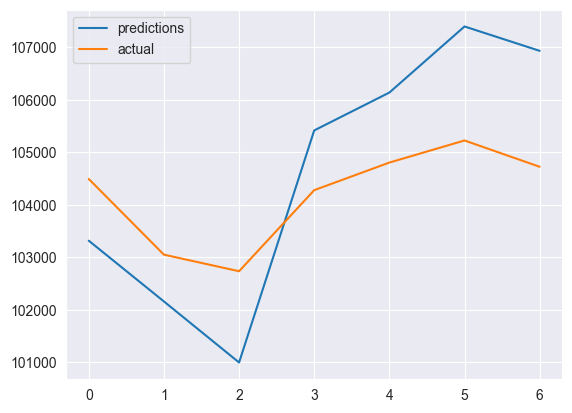

In [8]:
comparison = pd.DataFrame(predictions, y_test_rescaled).reset_index()
comparison.columns = ['predictions', 'actual']
# get latest date from data and add the number of rows in X_test to it
comparison.plot.line()

In [9]:
originalModel = clone(xgb_model, safe=True)

custom_param_grid = {
        'n_estimators': [30, 50, 100],
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 5, 8, 15],
        'subsample': [0.8, 1.0]
    }
xgb_model.tune_hyperparameters(X_train, y_train, param_grid=custom_param_grid, cv=5)

100%|██████████| 72/72 [01:20<00:00,  1.12s/it]


{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 30, 'subsample': 1.0}

<Axes: >

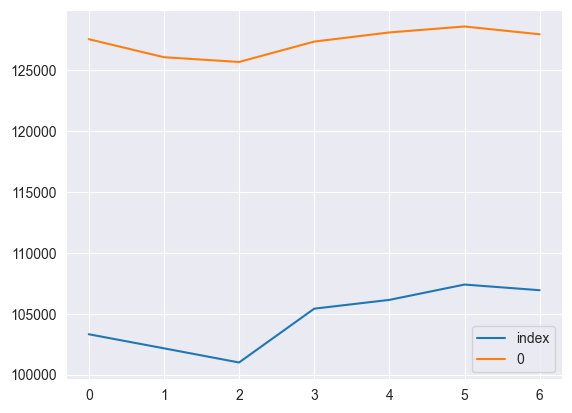

In [10]:
best_model = xgb_model.fit_best(X_train, y_train)
predictions = best_model.predict(X_test)
predictions = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
y_test_rescaled = target_scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
comparison = pd.DataFrame(predictions, y_test_rescaled).reset_index()
comparison.plot.line()

In [11]:
comparison.to_csv('plots/XGB_best_comparison.csv', index=True)
best_model.save('models/xgb_best_model.pkl')
originalModel.save('models/xgb_original_model.pkl')

# Create backtracking function from close price

Load Models

In [46]:
transformer = torch.load('models/BTC_full_model.pth')
with open('models/xgb_original_model.pkl', 'rb') as f:
    originalModel = pickle.load(f)

In [54]:
daily_data = merged[-LIMIT:]
daily_data = transformerDataSetup(daily_data)
X_train, X_test, y_train, y_test, _, _ = transformerXTrainYTrain(daily_data[-LIMIT:], testSize=len(daily_data)-TEST_DAYS)
X_train_norm, X_test_norm, y_train_norm, y_test_norm, sequence_scaler, target_scaler = normalize(X_train, X_test, y_train, y_test)

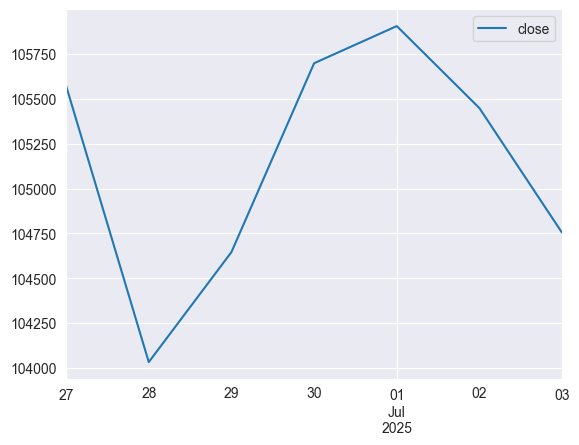

,close
2025-06-27,105572.58
2025-06-28,104033.26
2025-06-29,104645.87
2025-06-30,105697.94
2025-07-01,105904.94
2025-07-02,105447.82
2025-07-03,104753.38


In [55]:
backtracked = predictNextNDaysTransformer(transformer, daily_data, sequence_scaler)
backtracked = pd.DataFrame(backtracked)
backtracked

In [63]:
# Recalculate metrics based on predicted close price from the transformer
backtracked[f'SMA_{TEST_DAYS}'] = backtracked['close'].rolling(TEST_DAYS).mean().fillna(method='bfill')
backtracked['BB_STD'] = backtracked['close'].rolling(TEST_DAYS).std().fillna(method='bfill')
backtracked['BB_Lower'] = backtracked[f'close']-2*backtracked['BB_STD']
backtracked['BB_Upper'] = backtracked[f'close']+2*backtracked['BB_STD']
backtracked['value'] = daily_data['value'].iloc[0]
backtracked

,close,SMA_7,BB_STD,BB_Lower,BB_Upper,value
2025-06-27,105572.58,105150.827143,682.64207,104207.29586,106937.86414,45.0
2025-06-28,104033.26,105150.827143,682.64207,102667.97586,105398.54414,45.0
2025-06-29,104645.87,105150.827143,682.64207,103280.58586,106011.15414,45.0
2025-06-30,105697.94,105150.827143,682.64207,104332.65586,107063.22414,45.0
2025-07-01,105904.94,105150.827143,682.64207,104539.65586,107270.22414,45.0
2025-07-02,105447.82,105150.827143,682.64207,104082.53586,106813.10414,45.0
2025-07-03,104753.38,105150.827143,682.64207,103388.09586,106118.66414,45.0


In [73]:
backtracked_norm, _, _, _, sequence_scaler, target_scaler = normalize_regular(backtracked, backtracked, backtracked['close'], backtracked['close'])
predictions = originalModel.predict(backtracked_norm[trainingCols])
predictions = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
predictions

array([105150.82714286, 105150.82714286, 105150.82714286, 105150.82714286,
       105150.82714286, 105150.82714286, 105150.82714286])

In [74]:
backtracked['close'].mean()

105150.82714285713